# AlfaisalX Technical Challenge — PneumoniaMNIST by Sardor Mamarsulov

This Colab notebook implements **Task 1 (CNN Classification)** and **Task 3 (Semantic Retrieval) end-to-end.

In [23]:
# ===== 0) Install dependencies (Colab) =====
!pip -q install medmnist==3.0.2
!pip -q install scikit-learn matplotlib tqdm
!pip -q install faiss-cpu open_clip_torch pillow


In [24]:
# ===== 1) Imports & global config =====
import os, math, random, json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms

from medmnist import PneumoniaMNIST

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

ROOT = Path(".")
(ROOT / "models").mkdir(exist_ok=True, parents=True)
(ROOT / "reports" / "figures").mkdir(exist_ok=True, parents=True)

# Small helper for nicer plots
def show_grid(images, titles=None, ncols=6, figsize=(12, 6)):
    n = len(images)
    nrows = math.ceil(n / ncols)
    plt.figure(figsize=figsize)
    for i, img in enumerate(images):
        ax = plt.subplot(nrows, ncols, i+1)
        ax.imshow(img, cmap="gray")
        ax.axis("off")
        if titles is not None:
            ax.set_title(titles[i], fontsize=8)
    plt.tight_layout()
    plt.show()


Device: cuda


Sizes: 4708 524 624


/tmp/ipython-input-1157806746.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  titles.append(f"y={int(y)}")


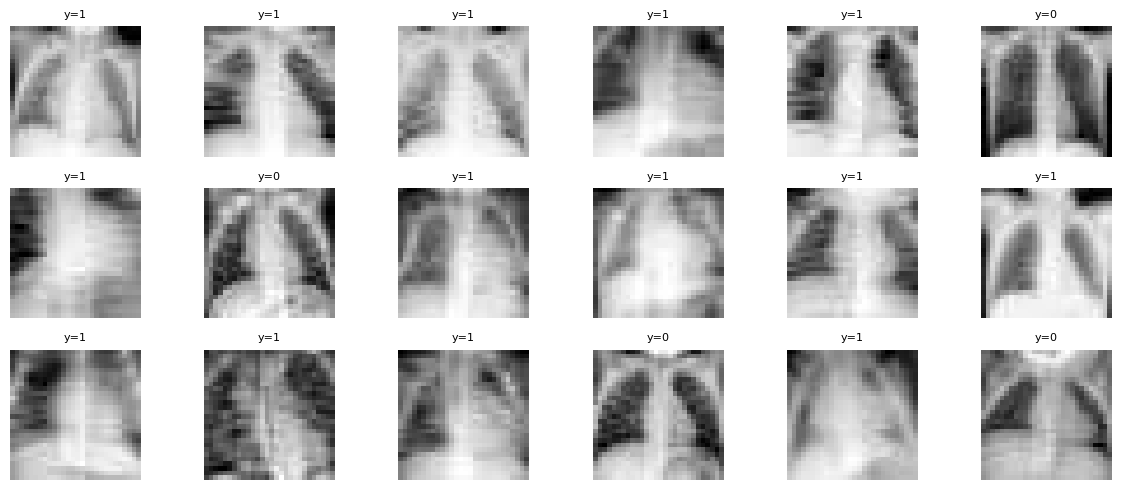

In [25]:
# ===== 2) Load raw datasets & quick sanity check =====
train_raw = PneumoniaMNIST(split="train", download=True)
val_raw   = PneumoniaMNIST(split="val", download=True)
test_raw  = PneumoniaMNIST(split="test", download=True)

print("Sizes:", len(train_raw), len(val_raw), len(test_raw))

# Peek a few images
imgs = []
titles = []
for i in range(18):
    x, y = train_raw[i]
    imgs.append(np.array(x))
    titles.append(f"y={int(y)}")
show_grid(imgs, titles=titles, ncols=6, figsize=(12, 5))


In [26]:
# ===== 3) Compute training mean/std for normalization =====
tmp = PneumoniaMNIST(split="train", transform=transforms.ToTensor(), download=True)
loader = DataLoader(tmp, batch_size=256, shuffle=True, num_workers=0)

means, stds = [], []
for i, (x, _) in enumerate(loader):
    if i >= 50:  # fast estimate
        break
    means.append(x.mean().item())
    stds.append(x.std().item())

mean = float(np.mean(means))
std  = float(np.mean(stds)) if float(np.mean(stds)) > 1e-6 else 1.0
print("Estimated mean/std:", mean, std)


Estimated mean/std: 0.5719344521823683 0.1681324557254189


In [27]:
# ===== 4) Task 1 transforms & dataloaders =====
train_tfm = transforms.Compose([
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean], std=[std]),
])

test_tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean], std=[std]),
])

train_ds = PneumoniaMNIST(split="train", transform=train_tfm, download=True)
val_ds   = PneumoniaMNIST(split="val", transform=test_tfm, download=True)
test_ds  = PneumoniaMNIST(split="test", transform=test_tfm, download=True)

BATCH_SIZE = 128
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Class balance (for pos_weight)
ys = []
# Fix: Apply ToTensor() transform to the dataset used for class balance calculation
class_balance_tfm = transforms.Compose([transforms.ToTensor()])
for _, y in DataLoader(PneumoniaMNIST(split="train", download=True, transform=class_balance_tfm), batch_size=512):
    ys.append(y.numpy().reshape(-1))
y_all = np.concatenate(ys).astype(int)
pos = (y_all==1).sum()
neg = (y_all==0).sum()
pos_weight = torch.tensor([neg / max(pos, 1)], dtype=torch.float32).to(DEVICE)
print(f"Train class counts: neg={neg}, pos={pos}, pos_weight={pos_weight.item():.3f}")


Train class counts: neg=1214, pos=3494, pos_weight=0.347


In [28]:
# ===== 5) Task 1 model =====
class PneumoniaCNN(nn.Module):
    def __init__(self, dropout=0.2):
        super().__init__()
        def block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            )
        self.features = nn.Sequential(
            block(1, 32),
            block(32, 32),
            nn.MaxPool2d(2),  # 14x14
            block(32, 64),
            block(64, 64),
            nn.MaxPool2d(2),  # 7x7
            block(64, 128),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

model = PneumoniaCNN(dropout=0.2).to(DEVICE)
print(model)


PneumoniaCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (4): Sequential(
      (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affi

In [29]:
# ===== 6) Task 1 training loop (early stopping on val AUC) =====
from tqdm import tqdm
from sklearn.metrics import roc_auc_score

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

def eval_auc(loader):
    model.eval()
    probs, ys = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE).float().view(-1)
            logits = model(x).view(-1)
            p = torch.sigmoid(logits)
            probs.append(p.cpu().numpy())
            ys.append(y.cpu().numpy())
    probs = np.concatenate(probs)
    ys = np.concatenate(ys).astype(int)
    return float(roc_auc_score(ys, probs))

EPOCHS = 20
best_auc = -1
patience = 5
bad = 0

history = {"train_loss": [], "val_auc": []}

for epoch in range(1, EPOCHS+1):
    model.train()
    running = 0.0
    for x, y in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False):
        x = x.to(DEVICE)
        y = y.to(DEVICE).float()

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running += loss.item() * x.size(0)

    train_loss = running / len(train_ds)
    val_auc = eval_auc(val_loader)
    scheduler.step(val_auc)

    history["train_loss"].append(train_loss)
    history["val_auc"].append(val_auc)
    print(f"Epoch {epoch}: train_loss={train_loss:.4f}  val_auc={val_auc:.4f}")

    if val_auc > best_auc:
        best_auc = val_auc
        bad = 0
        torch.save({"model_state": model.state_dict(), "mean": mean, "std": std}, "models/task1_cnn_best.pt")
    else:
        bad += 1
        if bad >= patience:
            print("Early stopping triggered.")
            break

print("Best val AUC:", best_auc)


Epoch 1: train_loss=0.1636  val_auc=0.9692


Epoch 2: train_loss=0.0974  val_auc=0.9864


Epoch 3: train_loss=0.0752  val_auc=0.9872


Epoch 4: train_loss=0.0680  val_auc=0.9905


Epoch 5: train_loss=0.0641  val_auc=0.9920


...

Epoch 16: train_loss=0.0403  val_auc=0.9968


Epoch 17: train_loss=0.0373  val_auc=0.9971


Epoch 18: train_loss=0.0323  val_auc=0.9974


Epoch 19: train_loss=0.0349  val_auc=0.9969


Epoch 20: train_loss=0.0302  val_auc=0.9974
Best val AUC: 0.9974293059125964


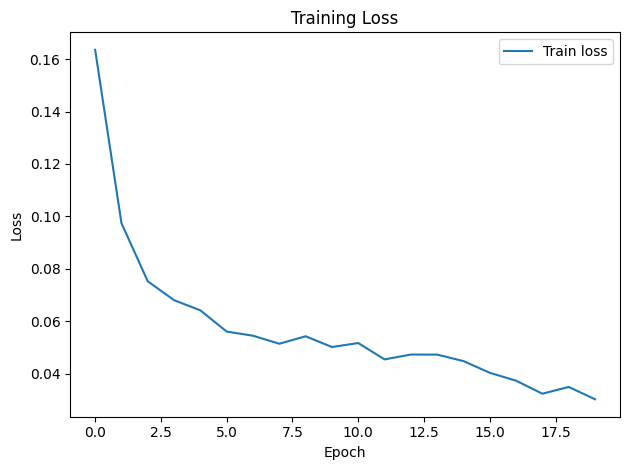

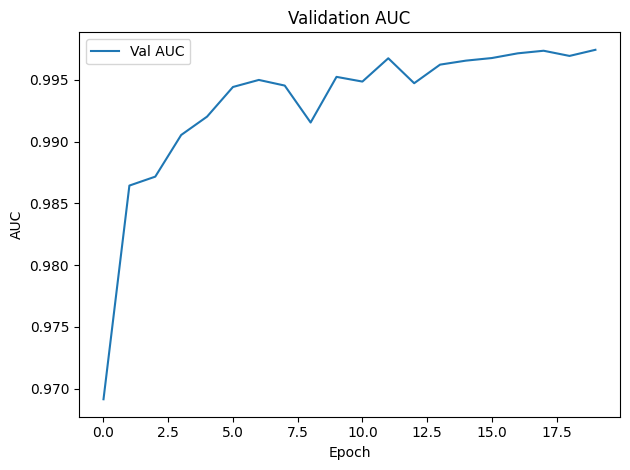

In [30]:
# ===== 7) Plot training curves =====
fig_path = Path("reports/figures/task1_training_curves.png")
plt.figure()
plt.plot(history["train_loss"], label="Train loss")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(fig_path, dpi=200)
plt.show()

fig_path = Path("reports/figures/task1_val_auc.png")
plt.figure()
plt.plot(history["val_auc"], label="Val AUC")
plt.title("Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.tight_layout()
plt.savefig(fig_path, dpi=200)
plt.show()


Test metrics
  Accuracy : 0.8317
  Precision: 0.7879
  Recall   : 1.0000
  F1       : 0.8814
  AUC      : 0.9762


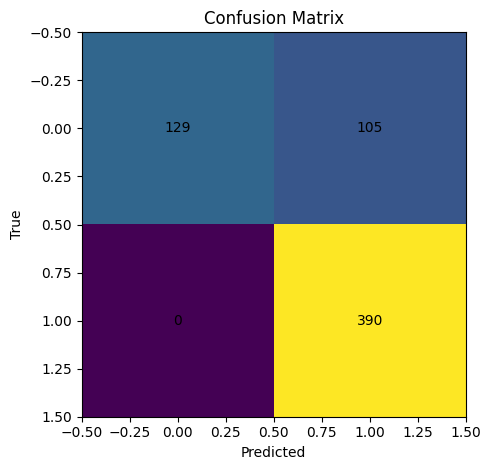

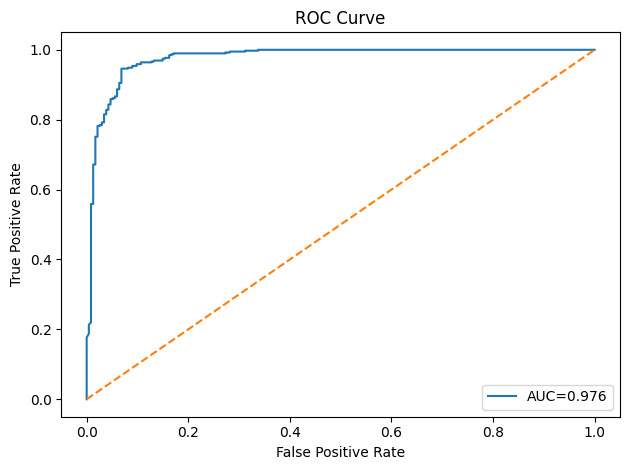

In [31]:
# ===== 8) Task 1 evaluation on test set (metrics + confusion matrix + ROC) =====
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)

# Load best
ckpt = torch.load("models/task1_cnn_best.pt", map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()

probs, ys = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        logits = model(x).view(-1)
        p = torch.sigmoid(logits).cpu().numpy()
        probs.append(p)
        ys.append(y.numpy().reshape(-1))

probs = np.concatenate(probs)
ys = np.concatenate(ys).astype(int)
pred = (probs >= 0.5).astype(int)

acc = accuracy_score(ys, pred)
prec, rec, f1, _ = precision_recall_fscore_support(ys, pred, average="binary", zero_division=0)
auc = roc_auc_score(ys, probs)
cm = confusion_matrix(ys, pred)

print("Test metrics")
print(f"  Accuracy : {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall   : {rec:.4f}")
print(f"  F1       : {f1:.4f}")
print(f"  AUC      : {auc:.4f}")

# Confusion matrix
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha="center", va="center")
plt.tight_layout()
plt.savefig("reports/figures/task1_confusion_matrix.png", dpi=200)
plt.show()

# ROC
fpr, tpr, _ = roc_curve(ys, probs)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig("reports/figures/task1_roc_curve.png", dpi=200)
plt.show()


Misclassified: 105 out of 624


/tmp/ipython-input-2275861667.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  titles.append(f"T={int(y_raw)} P={int(pred[i])} p={probs[i]:.2f}")


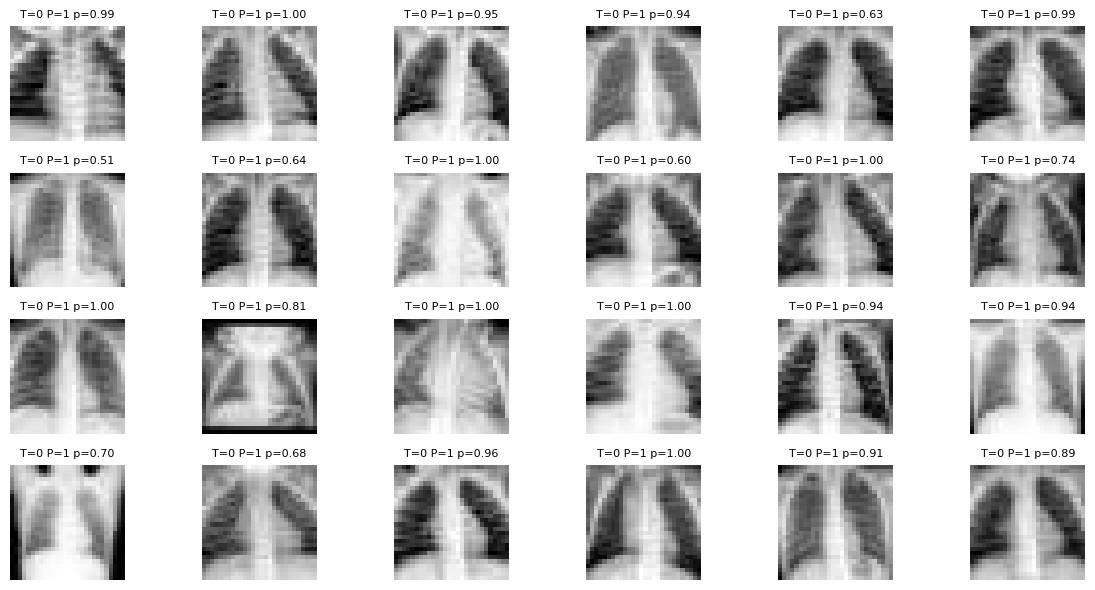

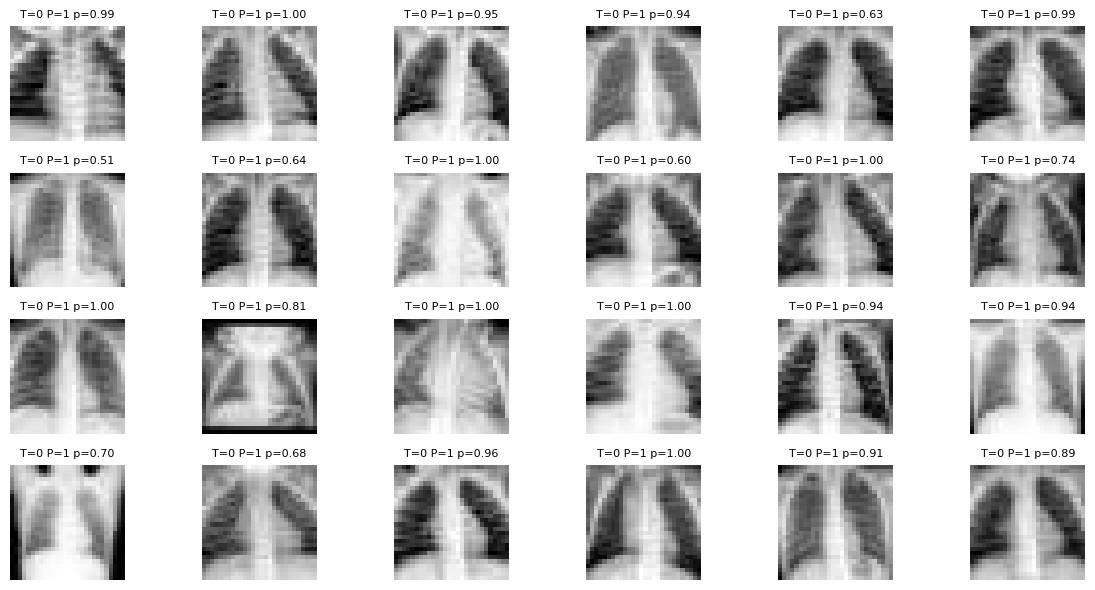

In [32]:
# ===== 9) Task 1 failure cases (misclassified images) =====
# Identify misclassified indices
mis_idx = np.where(pred != ys)[0]
print("Misclassified:", len(mis_idx), "out of", len(ys))

# Show up to 24 failure cases
n_show = min(24, len(mis_idx))
idxs = mis_idx[:n_show]

imgs = []
titles = []
for i in idxs:
    x_raw, y_raw = test_raw[i]   # raw PIL + label
    imgs.append(np.array(x_raw))
    titles.append(f"T={int(y_raw)} P={int(pred[i])} p={probs[i]:.2f}")

show_grid(imgs, titles=titles, ncols=6, figsize=(12, 6))

# Save a figure with first 24 failures
fig_path = Path("reports/figures/task1_failure_cases.png")
plt.figure(figsize=(12, 6))
for j, i in enumerate(idxs):
    ax = plt.subplot(math.ceil(n_show/6), 6, j+1)
    ax.imshow(np.array(test_raw[i][0]), cmap="gray")
    ax.axis("off")
    ax.set_title(titles[j], fontsize=8)
plt.tight_layout()
plt.savefig(fig_path, dpi=200)
plt.show()


In [33]:
# ===== 10) Auto-generate Task 1 markdown report =====
report_path = Path("reports/task1 classification report.md")

md = f"""# Task 1 — CNN Classification Report (PneumoniaMNIST)

## 1. Model Architecture & Justification
- **Model**: Lightweight CNN (Conv-BN-ReLU blocks + pooling + global average pooling + linear head).
- **Rationale**: Designed for **28×28 grayscale** images, trains quickly on CPU while keeping enough capacity for pneumonia patterns.

## 2. Training Methodology & Hyperparameters
- Dataset: MedMNIST v2 **PneumoniaMNIST**
- Input: 1×28×28, normalized with training mean/std (**mean={mean:.4f}**, **std={std:.4f}**)
- Augmentation: random rotation (±10°) + small affine translate/scale
- Loss: `BCEWithLogitsLoss` with `pos_weight={pos_weight.item():.3f}` to mitigate class imbalance
- Optimizer: AdamW (lr=1e-3, weight_decay=1e-4)
- Scheduler: ReduceLROnPlateau (monitors validation AUC)
- Early stopping: patience={patience} epochs (monitors val AUC)

## 3. Evaluation Metrics (Test Set)
- **Accuracy**: {acc:.4f}
- **Precision**: {prec:.4f}
- **Recall**: {rec:.4f}
- **F1-score**: {f1:.4f}
- **ROC-AUC**: {auc:.4f}

### Figures
- Training loss: `reports/figures/task1_training_curves.png`
- Validation AUC: `reports/figures/task1_val_auc.png`
- Confusion matrix: `reports/figures/task1_confusion_matrix.png`
- ROC curve: `reports/figures/task1_roc_curve.png`
- Failure cases: `reports/figures/task1_failure_cases.png`

## 4. Failure Case Analysis (quick observations)
- Misclassified test images: **{len(mis_idx)} / {len(ys)}**
- Common patterns:
  - Very low-contrast or noisy images (hard even for humans).
  - Borderline cases where visual signs are subtle.
  - Potential label noise or ambiguous samples (small 28×28 crop can remove context).

## 5. Discussion: Strengths, Limitations, Improvements
**Strengths**
- Simple, fast, reproducible pipeline; strong baseline for small medical images.
- Includes thorough evaluation and error inspection.

**Limitations**
- 28×28 resolution limits fine-grained findings.
- Single-task supervised training may not yield embeddings optimal for retrieval.

**If more time**
- Try MedMNIST+ 224 size with a pretrained backbone.
- Add calibration (temperature scaling), threshold tuning, and uncertainty estimation.
"""

report_path.write_text(md, encoding="utf-8")
print("Wrote:", report_path)


Wrote: reports/task1 classification report.md


## Task 3 — Semantic Retrieval (BiomedCLIP + FAISS)

We will build a content-based retrieval system using **BiomedCLIP** embeddings and a **FAISS** index. This supports:
- **Image → Image** retrieval
- **Text → Image** retrieval (because BiomedCLIP is vision-language)

We also compute **Precision@k** on the test set.

In [34]:
# ===== 11) Load BiomedCLIP (OpenCLIP) =====
from open_clip import create_model_from_pretrained, get_tokenizer
from PIL import Image

MODEL_ID = "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
CONTEXT_LEN = 256

biomedclip, preprocess = create_model_from_pretrained(MODEL_ID)
tokenizer = get_tokenizer(MODEL_ID)

biomedclip = biomedclip.to(DEVICE).eval()
print("Loaded:", MODEL_ID)


Loaded: hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224


In [35]:
# ===== 12) Build embedding dataset & compute image embeddings for test set =====
def _pil_rgb(x):
    if isinstance(x, Image.Image):
        return x.convert("RGB")
    return Image.fromarray(np.array(x)).convert("RGB")

embed_tfm = transforms.Lambda(lambda img: preprocess(_pil_rgb(img)))
test_embed_ds = PneumoniaMNIST(split="test", transform=embed_tfm, download=True)

embed_loader = DataLoader(test_embed_ds, batch_size=64, shuffle=False, num_workers=2)

@torch.no_grad()
def compute_image_embeddings(loader):
    feats = []
    labels = []
    for x, y in tqdm(loader, desc="Embedding test images"):
        x = x.to(DEVICE)
        f = biomedclip.encode_image(x)
        f = f / f.norm(dim=-1, keepdim=True)
        feats.append(f.cpu().numpy().astype("float32"))
        labels.append(y.numpy().reshape(-1))
    return np.vstack(feats), np.concatenate(labels).astype(int)

test_embs, test_labels = compute_image_embeddings(embed_loader)
print("Embeddings shape:", test_embs.shape)


Embedding test images: 100%|██████████| 10/10 [00:07<00:00,  1.33it/s]

Embeddings shape: (624, 512)


In [36]:
# ===== 13) Build FAISS index (cosine similarity via inner product on normalized vectors) =====
import faiss

dim = test_embs.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(test_embs)

# Save artifacts
np.save("reports/task3_test_embeddings.npy", test_embs)
np.save("reports/task3_test_labels.npy", test_labels)
faiss.write_index(index, "reports/task3_faiss.index")

print("FAISS index size:", index.ntotal)


FAISS index size: 624


In [37]:
# ===== 14) Precision@k evaluation =====
def precision_at_k(index, embs, labels, k=5):
    D, I = index.search(embs, k+1)  # +1 for self-match
    correct = 0
    total = 0
    for q in range(len(labels)):
        retrieved = [i for i in I[q].tolist() if i != q][:k]
        if len(retrieved) < k:
            continue
        correct += sum(labels[i] == labels[q] for i in retrieved)
        total += k
    return correct / max(total, 1)

p1  = precision_at_k(index, test_embs, test_labels, k=1)
p5  = precision_at_k(index, test_embs, test_labels, k=5)
p10 = precision_at_k(index, test_embs, test_labels, k=10)

print(f"Precision@1 : {p1:.4f}")
print(f"Precision@5 : {p5:.4f}")
print(f"Precision@10: {p10:.4f}")


Precision@1 : 0.8686
Precision@5 : 0.8529
Precision@10: 0.8389


/tmp/ipython-input-3146826565.py:44: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  titles.append(f"{title_prefix}QUERY\nlabel={int(q_y)}")
/tmp/ipython-input-3146826565.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  titles.append(f"idx={i}\nlabel={int(y)}\nsim={s:.2f}")


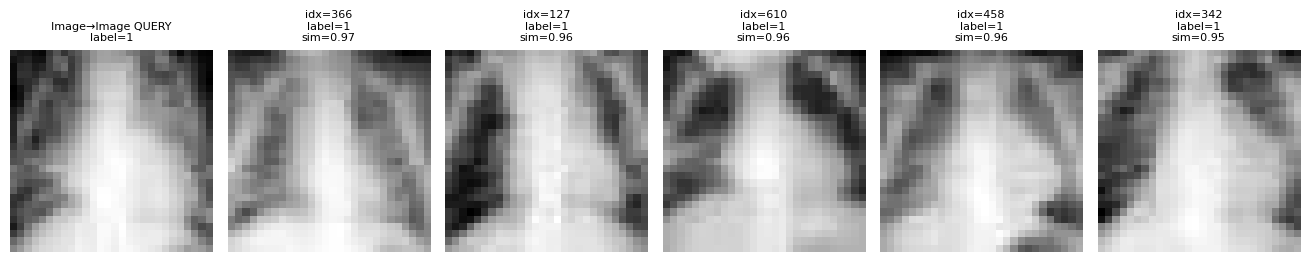

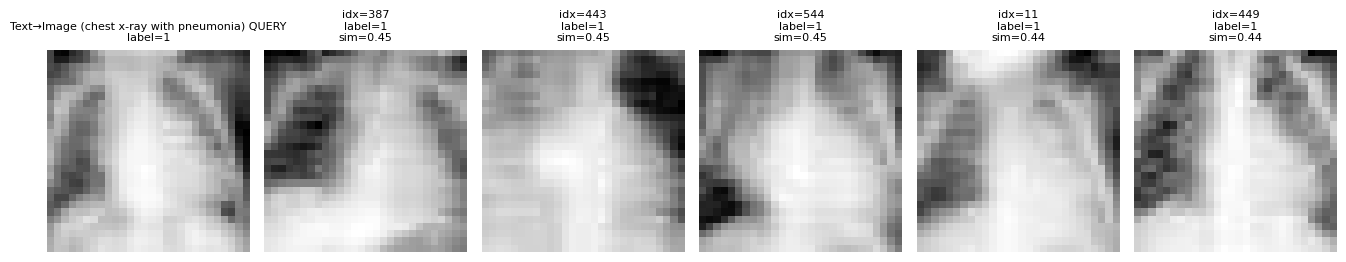

In [38]:
# ===== 15) Retrieval interfaces (Image→Image and Text→Image) + visualization =====
from transformers import AutoTokenizer

# The original open_clip tokenizer is causing issues with batch_encode_plus.
# We'll use transformers' AutoTokenizer directly for text tokenization.
# The text component of BiomedCLIP is PubMedBERT_256.
_text_tokenizer = AutoTokenizer.from_pretrained("microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224")

@torch.no_grad()
def embed_text(text: str):
    # Use the transformers AutoTokenizer directly, which handles batching via __call__
    toks = _text_tokenizer(
        [text],
        return_tensors='pt',
        padding='max_length',
        truncation=True,
        max_length=CONTEXT_LEN
    ).input_ids.to(DEVICE)
    f = biomedclip.encode_text(toks)
    f = f / f.norm(dim=-1, keepdim=True)
    return f.cpu().numpy().astype("float32")

def retrieve_by_image(query_idx: int, k: int = 5):
    q = test_embs[query_idx:query_idx+1]
    D, I = index.search(q, k+1)
    # drop self
    idxs = [i for i in I[0].tolist() if i != query_idx][:k]
    sims = [float(d) for d, i in zip(D[0].tolist(), I[0].tolist()) if i != query_idx][:k]
    return idxs, sims

def retrieve_by_text(query_text: str, k: int = 5):
    q = embed_text(query_text)
    D, I = index.search(q, k)
    idxs = I[0].tolist()
    sims = [float(d) for d in D[0].tolist()]
    return idxs, sims

def visualize_retrieval(query_idx: int, idxs, sims, title_prefix=""):
    imgs = []
    titles = []

    q_img, q_y = test_raw[query_idx]
    imgs.append(np.array(q_img))
    titles.append(f"{title_prefix}QUERY\nlabel={int(q_y)}")

    for i, s in zip(idxs, sims):
        img, y = test_raw[i]
        imgs.append(np.array(img))
        titles.append(f"idx={i}\nlabel={int(y)}\nsim={s:.2f}")

    show_grid(imgs, titles=titles, ncols=len(imgs), figsize=(2.2*len(imgs), 3))

# Example 1: image → image
q = 10
idxs, sims = retrieve_by_image(q, k=5)
visualize_retrieval(q, idxs, sims, title_prefix="Image→Image ")

# Example 2: text → image
query_text = "chest x-ray with pneumonia"
idxs, sims = retrieve_by_text(query_text, k=5)
# For text queries, show a random query image just for layout (optional)
visualize_retrieval(query_idx=0, idxs=idxs, sims=sims, title_prefix=f"Text→Image ({query_text}) ")


In [40]:
# ===== 16) Save a retrieval example figure =====
# We'll save one image→image example and one text→image example to a single PNG.
import matplotlib.pyplot as plt

def save_retrieval_figure(query_idx: int, idxs, sims, out_path: str, header: str):
    imgs = []
    titles = []

    q_img, q_y = test_raw[query_idx]
    imgs.append(np.array(q_img))
    titles.append(f"{header}\nQUERY label={int(q_y)}")

    for i, s in zip(idxs, sims):
        img, y = test_raw[i]
        imgs.append(np.array(img))
        titles.append(f"idx={i} label={int(y)} sim={s:.2f}")

    n = len(imgs)
    plt.figure(figsize=(2.2*n, 3))
    for j in range(n):
        ax = plt.subplot(1, n, j+1)
        ax.imshow(imgs[j], cmap="gray")
        ax.axis("off")
        ax.set_title(titles[j], fontsize=8)
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()

q = 10
idxs, sims = retrieve_by_image(q, k=5)
save_retrieval_figure(q, idxs, sims, "reports/figures/task3_retrieval_image2image.png", "Image→Image")

qt = "pneumonia chest x-ray"
idxs_t, sims_t = retrieve_by_text(qt, k=5)
# Use an arbitrary query index just for visual template
save_retrieval_figure(0, idxs_t, sims_t, "reports/figures/task3_retrieval_text2image.png", f"Text→Image: {qt}")

print("Saved retrieval figures in reports/figures/")


/tmp/ipython-input-1474248095.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  titles.append(f"{header}\nQUERY label={int(q_y)}")
/tmp/ipython-input-1474248095.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  titles.append(f"idx={i} label={int(y)} sim={s:.2f}")


Saved retrieval figures in reports/figures/


In [43]:
# ===== 17) Auto-generate Task 3 markdown report =====
report_path = Path("reports/task3 retrieval system.md")

md = f"""# Task 3 — Semantic Image Retrieval System (PneumoniaMNIST)

## 1. Embedding Model Selection & Justification
- **Model**: BiomedCLIP (PubMedBERT + ViT), loaded from Hugging Face via OpenCLIP (`{MODEL_ID}`).
- **Why this model**: Biomedical-domain vision-language pretraining helps align medical imagery with text concepts and supports both image and text queries.

## 2. Vector Database / Similarity Search Implementation
- **Index**: FAISS `IndexFlatIP` (inner product)
- **Similarity**: Cosine similarity achieved by L2-normalizing all embeddings before indexing.

## 3. Retrieval Interfaces
### Image-to-Image
- Embed the query image using BiomedCLIP image encoder → retrieve nearest neighbors from FAISS.

### Text-to-Image
- Embed the query text using BiomedCLIP text encoder → retrieve nearest images from FAISS.

## 4. Quantitative Evaluation (Test Set)
- **Precision@1**: {p1:.4f}
- **Precision@5**: {p5:.4f}
- **Precision@10**: {p10:.4f}

## 5. Visualizations
- Image→Image example: `reports/figures/task3_retrieval_image2image.png`
- Text→Image example: `reports/figures/task3_retrieval_text2image.png`

## 6. Discussion: Retrieval Quality & Failure Cases
**What works well**
- Many retrieved items share the same label as the query, indicating label-consistent grouping.

**Common failure patterns**
- Low-contrast or ambiguous images can retrieve mixed-label neighbors.
- 28×28 resizing reduces clinically meaningful detail; embeddings may rely on coarse texture.

**If more time**
- Use MedMNIST+ (224×224) for higher-fidelity embeddings.
- Fine-tune BiomedCLIP or train a lightweight metric-learning head on PneumoniaMNIST.
- Hybrid retrieval (BiomedCLIP + Task1 CNN penultimate embeddings) to improve class separation.
"""

report_path.write_text(md, encoding="utf-8")
print("Wrote:", report_path)


Wrote: reports/task3 retrieval system.md


# Gonna export the code to upload to the github!
Exporting a ZIP

In [44]:
# ===== 18) Zip project artifacts for download =====
import shutil
from datetime import datetime

zip_name = f"alfaisalx_submission_{datetime.now().strftime('%Y%m%d_%H%M%S')}.zip"
# Add only relevant folders
paths_to_zip = ["models", "reports"]

shutil.make_archive(zip_name.replace(".zip",""), "zip", root_dir=".", base_dir=".")
print("Created:", zip_name)


Created: alfaisalx_submission_20260222_224742.zip
